In [1]:
# Neural Network Analysis Demo
# This notebook demonstrates how to use the NetworkAnalyzer and WeightBinning classes

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

# Add parent directory to Python path to import from sibling directories
import sys
import os
# Get the absolute path of the current notebook's directory
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
# Get the parent directory
parent_dir = os.path.dirname(notebook_dir)
# Add parent directory to path
sys.path.append(parent_dir)

from Architectures.permutation_free_architecture import PermutationFreeNet
from Classes.weight_binning import WeightBinning
from Classes.network_analyzer import NetworkAnalyzer

In [2]:
save_dir = "/home2/coles8/Large-Scale-Design-and-Analysis-of-Neural-Networks/outputs/networkComparison"
all_networks_dir = "/home2/coles8/savedNetworks/"

# Set the architecture, save directory, and load path
architecture = PermutationFreeNet
wb_save_dir = f"{save_dir}/binning" 
# load_path = f"{save_dir}/working_networks.pt"
load_path_reference = f"{all_networks_dir}/perm_free/accurateNetSubset700.pt"
load_path_phenotype = f"{all_networks_dir}/perm_free/accurateNetPhenotype.pt"

# Instantiate WeightBinning
wb_reference = WeightBinning(architecture=architecture, save_dir=wb_save_dir, load_path=load_path_reference)
wb_phenotype = WeightBinning(architecture=architecture, save_dir=wb_save_dir, load_path=load_path_phenotype)

Number of networks loaded:
700
Loaded models
Stored weights
Number of networks loaded:
700
Loaded models
Stored weights


In [6]:
# wb.analyze_distributions(
#     layer=0,
#     kl_threshold=0.001,
#     multi_peak=False,
#     peaks_per_layer=None,
#     random_state=42,
# )
layer_weight_distributions_reference = wb_reference.get_layer_weight_distributions()
layer_weight_distributions_phenotype = wb_phenotype.get_layer_weight_distributions()

print(len(layer_weight_distributions_reference))
print(len(layer_weight_distributions_phenotype))

5
5


Fitting GMM models...
Clustering GMMs with KL threshold 0.001...
Plotting unique GMM distributions for layer 0...
Plotting unique GMM cluster 0 at position (0, 0)


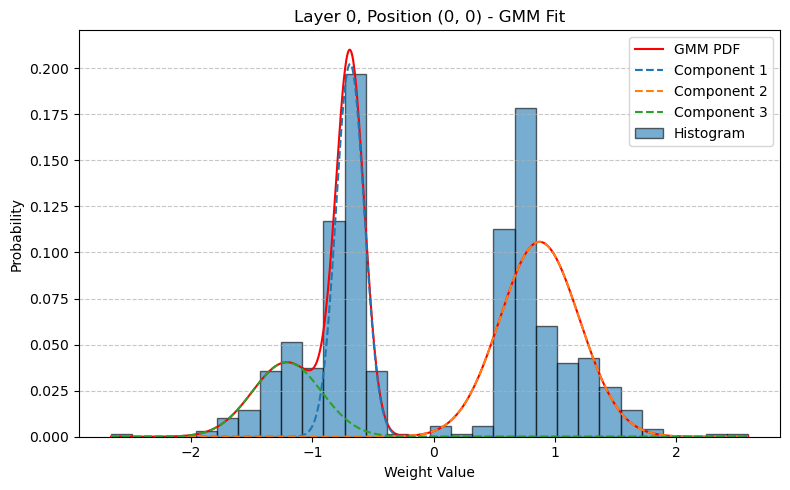

Plotting unique GMM cluster 1 at position (0, 1)


<Figure size 640x480 with 0 Axes>

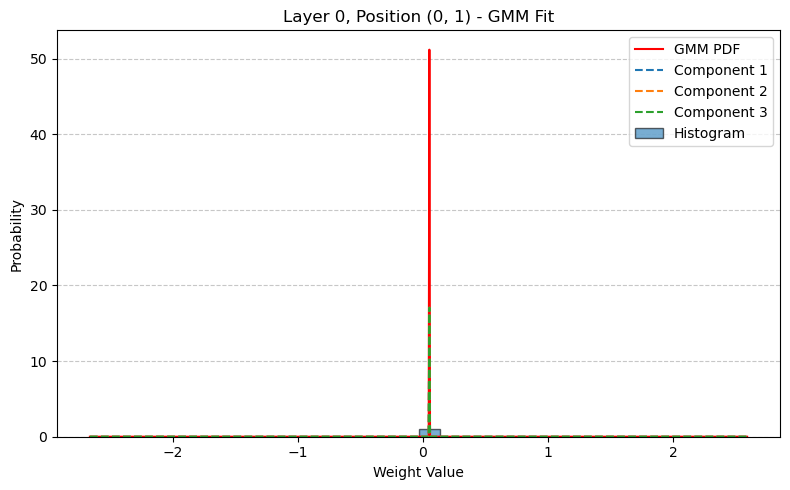

Plotting unique GMM cluster 2 at position (1, 0)


<Figure size 640x480 with 0 Axes>

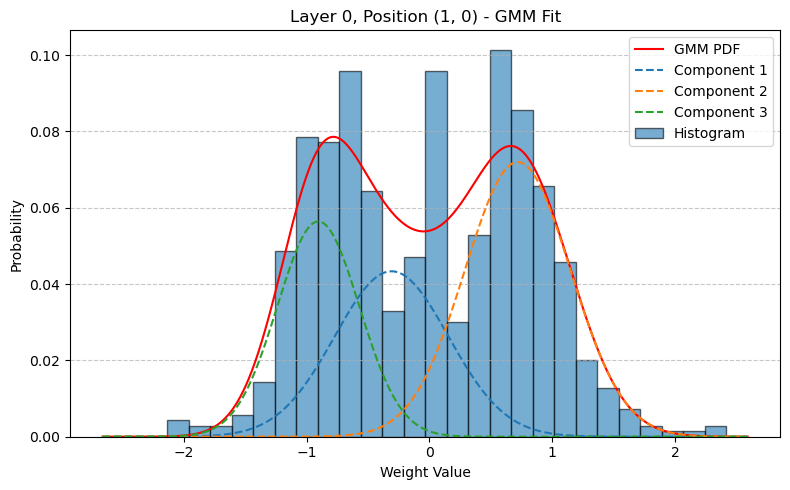

Plotting unique GMM cluster 3 at position (1, 1)


<Figure size 640x480 with 0 Axes>

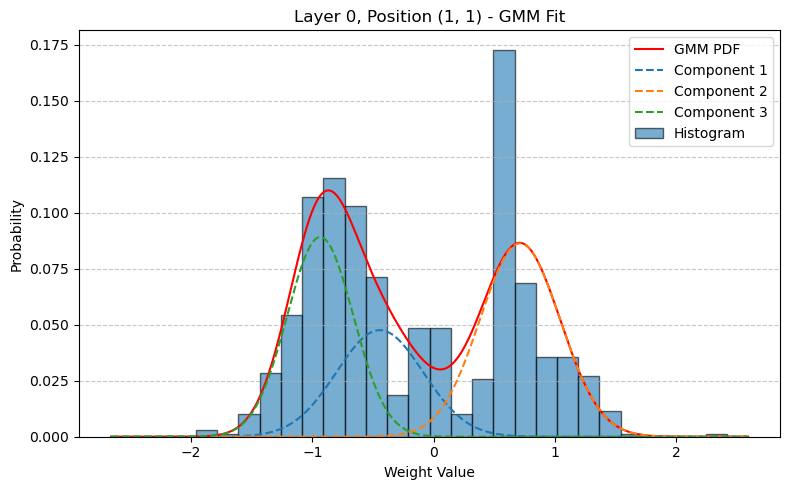

Plotting unique GMM cluster 4 at position (2, 1)


<Figure size 640x480 with 0 Axes>

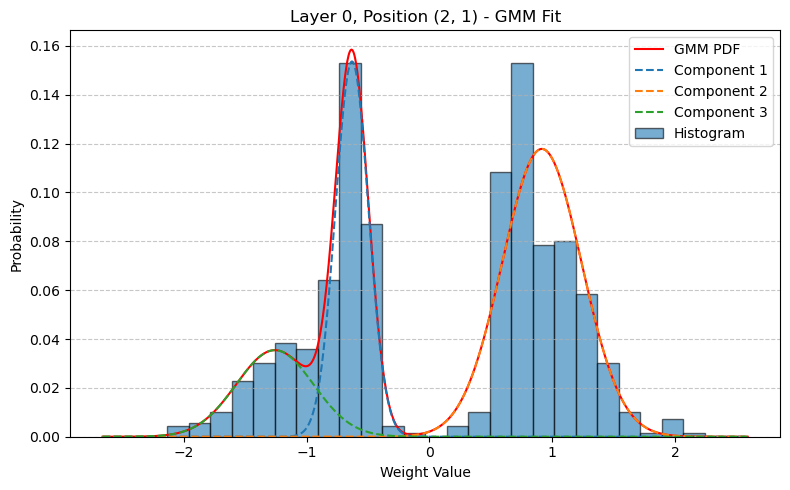

Found 5 unique GMM distributions in layer 0


[array([[0, 1],
        [2, 3],
        [1, 4]]),
 array([[0, 1, 2],
        [3, 1, 1],
        [4, 5, 1],
        [1, 6, 1],
        [1, 7, 8],
        [1, 1, 9]]),
 array([[ 0,  1,  2,  3,  3,  3],
        [ 3,  4,  5,  6,  3,  3],
        [ 3,  3,  7,  8,  9,  3],
        [ 3,  3,  3, 10, 11, 12],
        [13,  3,  3,  3, 14, 15],
        [16, 10,  3,  3,  3, 17]]),
 array([[ 0,  1,  2,  3,  3,  3],
        [ 3,  4,  5,  6,  3,  3],
        [ 3,  3,  7,  8,  9,  3],
        [ 3,  3,  3,  8, 10, 11],
        [11,  3,  3,  3, 12, 11],
        [13,  2,  3,  3,  3, 14]]),
 array([[0, 1, 2, 3, 4, 5]])]

<Figure size 640x480 with 0 Axes>

In [9]:
# For layer 0
wb_reference.analyze_distributions(
    layer=0,
    kl_threshold=0.001,
    multi_peak=True,
    peaks_per_layer=[3, 2, 2, 2, 2]
)

Fitting GMM models...
Clustering GMMs with KL threshold 0.001...
Plotting unique GMM distributions for layer 0...
Plotting unique GMM cluster 0 at position (0, 0)


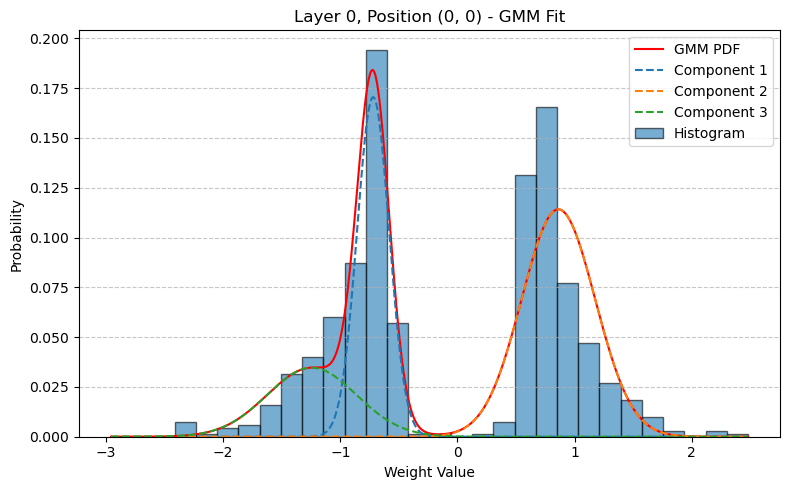

Plotting unique GMM cluster 1 at position (0, 1)


<Figure size 640x480 with 0 Axes>

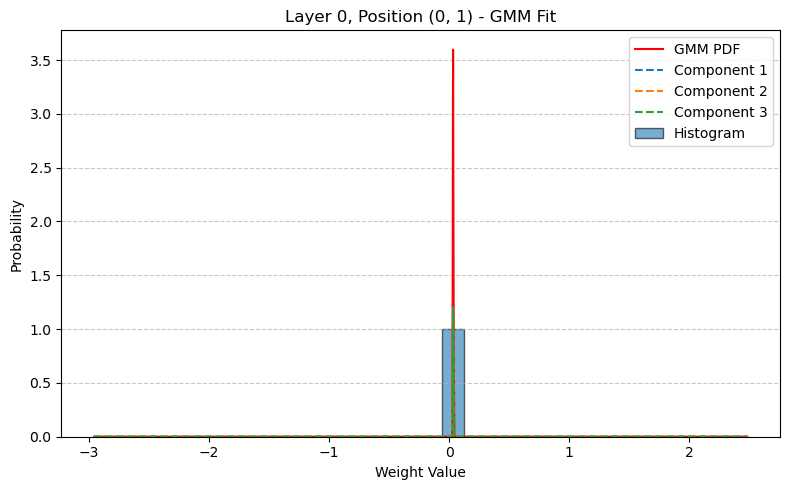

Plotting unique GMM cluster 2 at position (1, 0)


<Figure size 640x480 with 0 Axes>

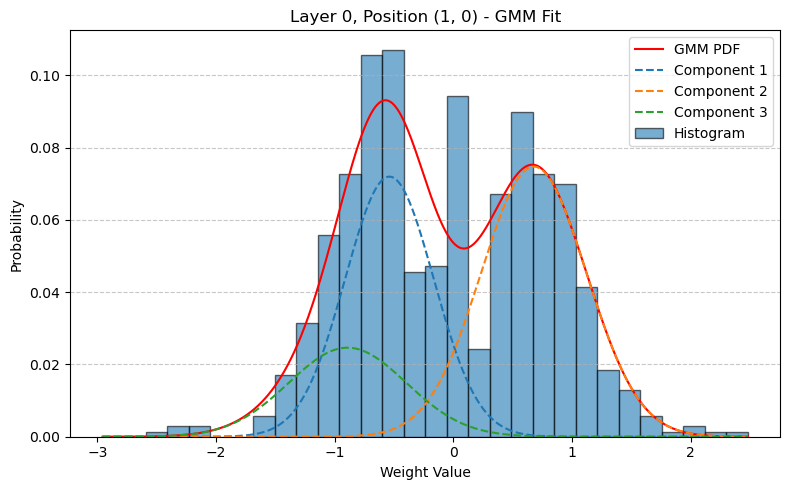

Plotting unique GMM cluster 3 at position (1, 1)


<Figure size 640x480 with 0 Axes>

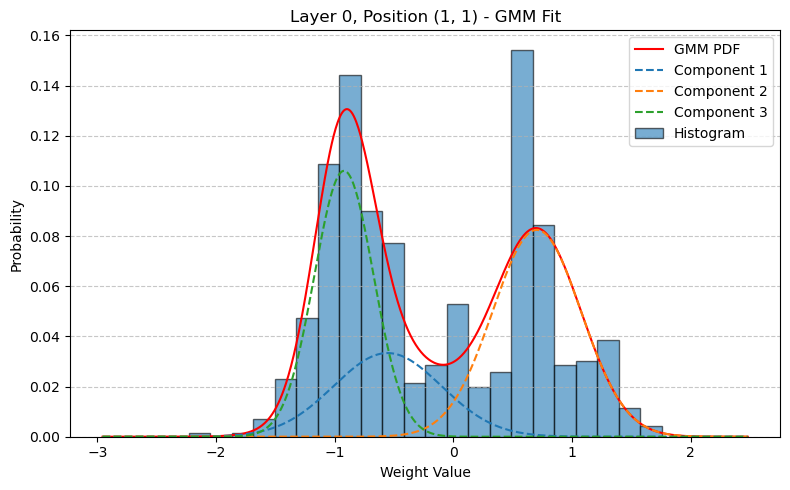

Plotting unique GMM cluster 4 at position (2, 1)


<Figure size 640x480 with 0 Axes>

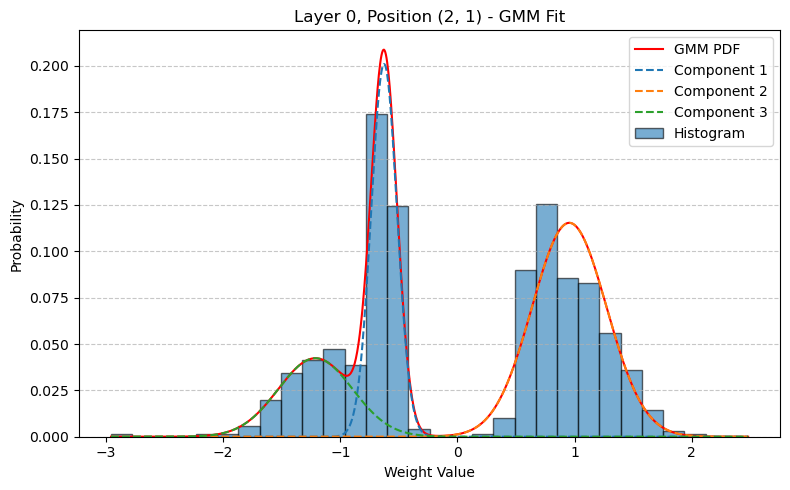

Found 5 unique GMM distributions in layer 0


[array([[0, 1],
        [2, 3],
        [1, 4]]),
 array([[0, 1, 2],
        [3, 1, 1],
        [4, 5, 1],
        [1, 6, 1],
        [1, 7, 8],
        [1, 1, 9]]),
 array([[ 0,  1,  2,  3,  3,  3],
        [ 3,  4,  5,  6,  3,  3],
        [ 3,  3,  7,  8,  9,  3],
        [ 3,  3,  3, 10, 11, 12],
        [13,  3,  3,  3, 14, 15],
        [16, 17,  3,  3,  3, 18]]),
 array([[ 0,  1,  2,  3,  3,  3],
        [ 3,  4,  5,  6,  3,  3],
        [ 3,  3,  6,  7,  8,  3],
        [ 3,  3,  3,  9,  8, 10],
        [ 2,  3,  3,  3, 11, 12],
        [13,  2,  3,  3,  3,  2]]),
 array([[0, 1, 2, 3, 4, 5]])]

<Figure size 640x480 with 0 Axes>

In [8]:
wb_phenotype.analyze_distributions(
    layer=0,
    kl_threshold=0.001,
    multi_peak=True,
    peaks_per_layer=[3, 2, 2, 2, 2]
)



reference:
[array([[0, 1],
        [2, 3],
        [1, 4]]),
 array([[0, 1, 2],
        [3, 1, 1],
        [4, 5, 1],
        [1, 6, 1],
        [1, 7, 8],
        [1, 1, 9]]),
 array([[ 0,  1,  2,  3,  3,  3],
        [ 3,  4,  5,  6,  3,  3],
        [ 3,  3,  7,  8,  9,  3],
        [ 3,  3,  3, 10, 11, 12],
        [13,  3,  3,  3, 14, 15],
        [16, 10,  3,  3,  3, 17]]),
 array([[ 0,  1,  2,  3,  3,  3],
        [ 3,  4,  5,  6,  3,  3],
        [ 3,  3,  7,  8,  9,  3],
        [ 3,  3,  3,  8, 10, 11],
        [11,  3,  3,  3, 12, 11],
        [13,  2,  3,  3,  3, 14]]),
 array([[0, 1, 2, 3, 4, 5]])]

phenotype:
[array([[0, 1],
        [2, 3],
        [1, 4]]),
 array([[0, 1, 2],
        [3, 1, 1],
        [4, 5, 1],
        [1, 6, 1],
        [1, 7, 8],
        [1, 1, 9]]),
 array([[ 0,  1,  2,  3,  3,  3],
        [ 3,  4,  5,  6,  3,  3],
        [ 3,  3,  7,  8,  9,  3],
        [ 3,  3,  3, 10, 11, 12],
        [13,  3,  3,  3, 14, 15],
        [16, 17,  3,  3,  3, 18]]),
 array([[ 0,  1,  2,  3,  3,  3],
        [ 3,  4,  5,  6,  3,  3],
        [ 3,  3,  6,  7,  8,  3],
        [ 3,  3,  3,  9,  8, 10],
        [ 2,  3,  3,  3, 11, 12],
        [13,  2,  3,  3,  3,  2]]),
 array([[0, 1, 2, 3, 4, 5]])]